In [1]:
import edes 
from edes.utils.plotting import plot, plot_ax, big_plt_font, plot_ax_errbar, plot_errbar
from edes.utils.plotting import plot_generated_timelines, generate_signal_timeline
import numpy as np 
from tqdm import tqdm, trange 
import matplotlib.pyplot as plt 
import time
from edes.utils.file_handling import load_h5_data, load_latest_data, load_latest_filename
big_plt_font()

In [2]:
file = load_latest_data() 
plot_errbar(file['all_V'], -np.mean(file['all_I'], axis=1)*1e9, yerr=np.std(file['all_I'], axis=1)*1e9, fmt='.--', xlabel='Tip voltage (V)', ylabel='Electrode current (nA)')
# plt.yscale('log')

KeyError: 'all_V'

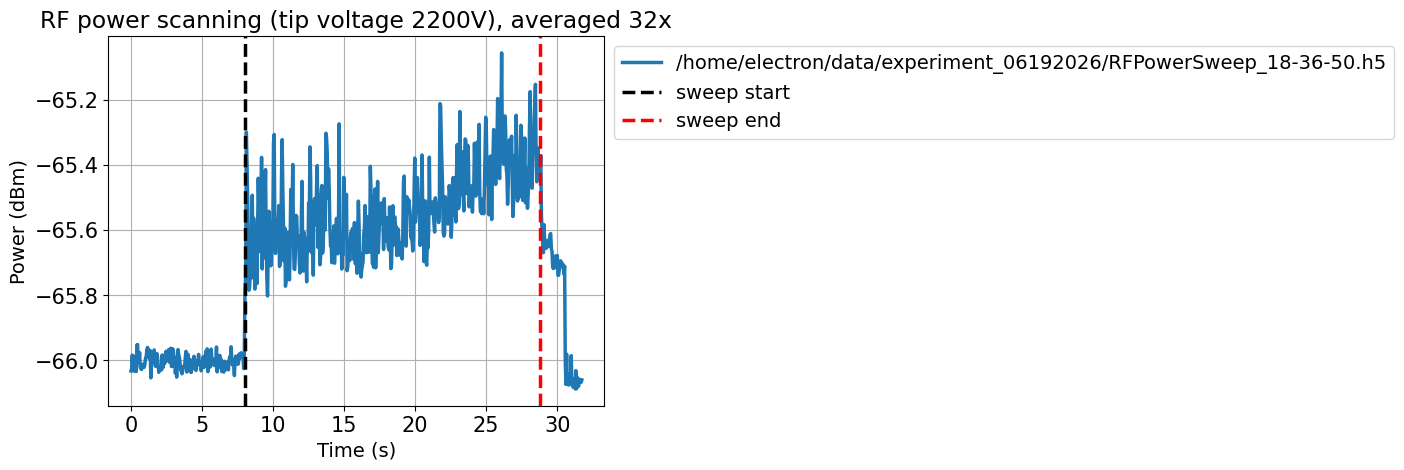

In [33]:
file = load_latest_data()
all_data = file['all_meas']
num_points = len(all_data[0])
t_axis = np.linspace(0, file['SSA_SWT'], num_points) 
idx = np.where(t_axis < file['t_end'][-1]-file['t_start'][-1]+file['t_valon_settle']+file['t_meas_delay']-1)
plot(t_axis[idx], np.mean(all_data, axis=0)[idx], xlabel='Time (s)', 
     ylabel='Power (dBm)', label=file['filename'], title=f"RF power scanning (tip voltage {file['V_on']}V), averaged {file['N_avg']}x")
plt.axvline(file['t_valon_settle'], linestyle='--', color='k', label='sweep start')
plt.axvline(file['t_end'][-1]-file['t_start'][-1]+file['t_valon_settle'], linestyle='--', color='r', label='sweep end') 
# plt.axvline(t_RF_on, linestyle='--', color='g', label='RF on') 
# plt.axvline(t_RF_off, linestyle='--', color='purple', label='RF off')
plt.legend(bbox_to_anchor=(1,1))
plt.show()


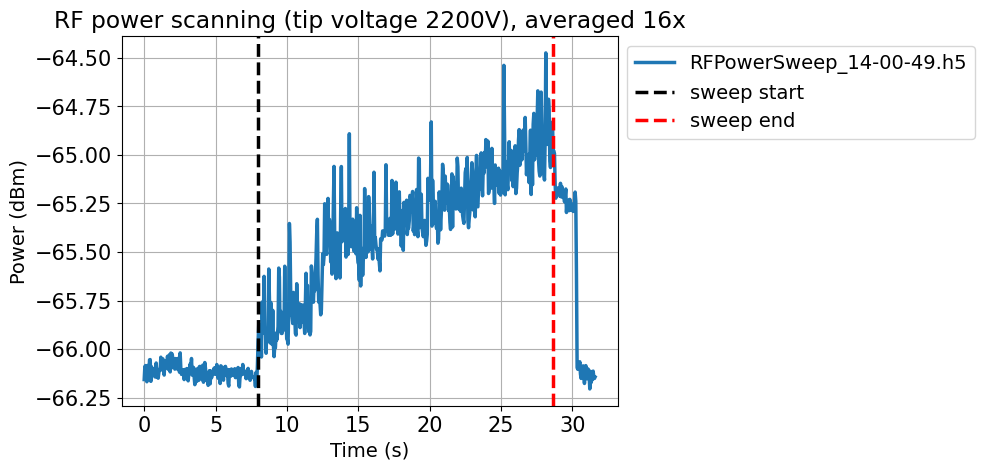

In [13]:

file = load_h5_data('RFPowerSweep_13-35-03.h5', base=f'{edes.load_saving_dir()}/experiment_06192026')
all_data = file['all_meas']
num_points = len(all_data[0])
t_axis = np.linspace(0, file['SSA_SWT'], num_points) 
idx = np.where(t_axis < file['t_end'][-1]-file['t_start'][-1]+file['t_valon_settle']+file['t_meas_delay']-1)
plot(t_axis[idx], np.mean(all_data, axis=0)[idx], xlabel='Time (s)', 
     ylabel='Power (dBm)', label='RFPowerSweep_14-00-49.h5', title=f"RF power scanning (tip voltage {file['V_on']}V), averaged {file['N_avg']}x")
plt.axvline(file['t_valon_settle'], linestyle='--', color='k', label='sweep start')
plt.axvline(file['t_end'][-1]-file['t_start'][-1]+file['t_valon_settle'], linestyle='--', color='r', label='sweep end') 
# plt.axvline(t_RF_on, linestyle='--', color='g', label='RF on') 
# plt.axvline(t_RF_off, linestyle='--', color='purple', label='RF off')
plt.legend(bbox_to_anchor=(1,1))
plt.show()


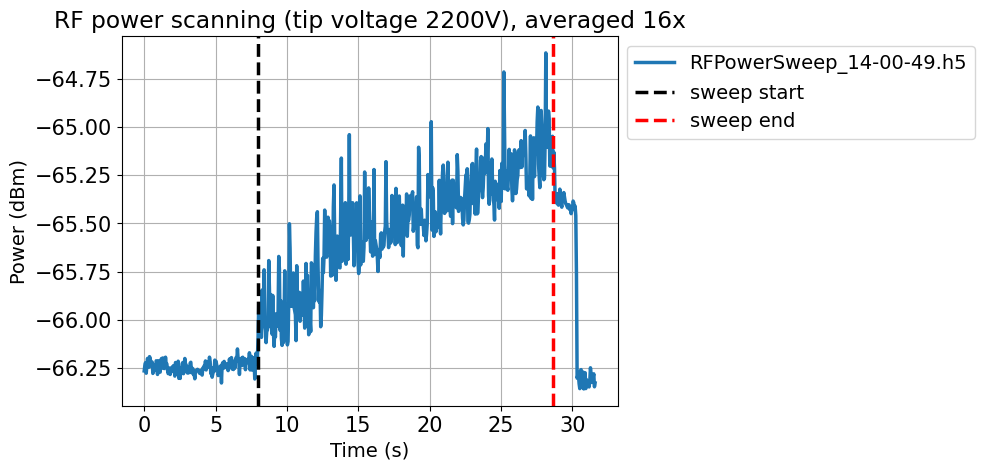

In [14]:

file = load_h5_data('RFPowerSweep_14-00-49.h5', base=f'{edes.load_saving_dir()}/experiment_06192026')
all_data = file['all_meas']
num_points = len(all_data[0])
t_axis = np.linspace(0, file['SSA_SWT'], num_points) 
idx = np.where(t_axis < file['t_end'][-1]-file['t_start'][-1]+file['t_valon_settle']+file['t_meas_delay']-1)
plot(t_axis[idx], np.mean(all_data, axis=0)[idx], xlabel='Time (s)', 
     ylabel='Power (dBm)', label='RFPowerSweep_14-00-49.h5', title=f"RF power scanning (tip voltage {file['V_on']}V), averaged {file['N_avg']}x")
plt.axvline(file['t_valon_settle'], linestyle='--', color='k', label='sweep start')
plt.axvline(file['t_end'][-1]-file['t_start'][-1]+file['t_valon_settle'], linestyle='--', color='r', label='sweep end') 
# plt.axvline(t_RF_on, linestyle='--', color='g', label='RF on') 
# plt.axvline(t_RF_off, linestyle='--', color='purple', label='RF off')
plt.legend(bbox_to_anchor=(1,1))
plt.show()


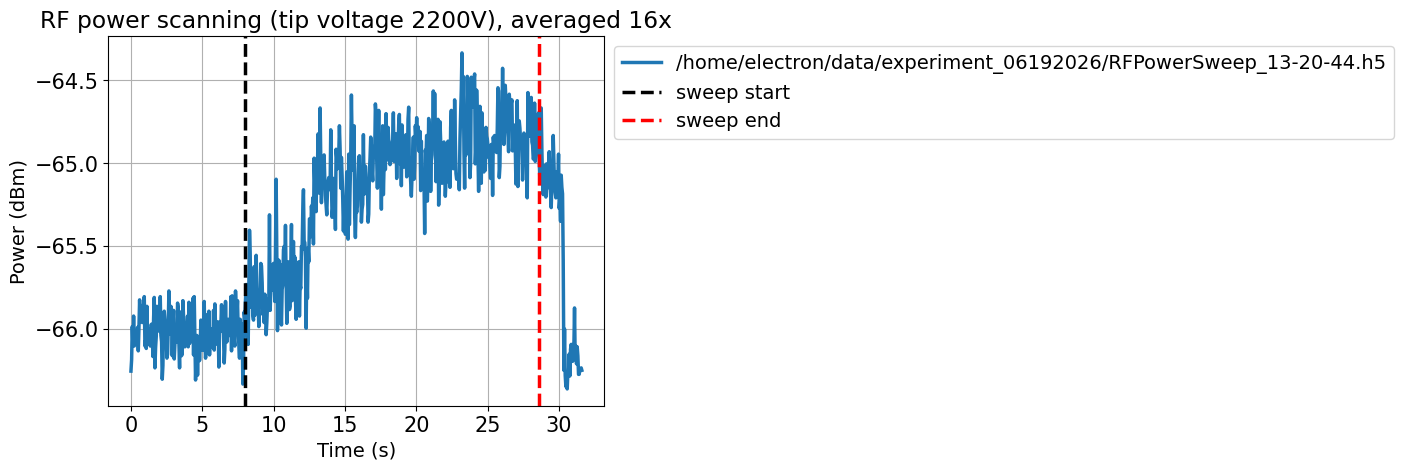

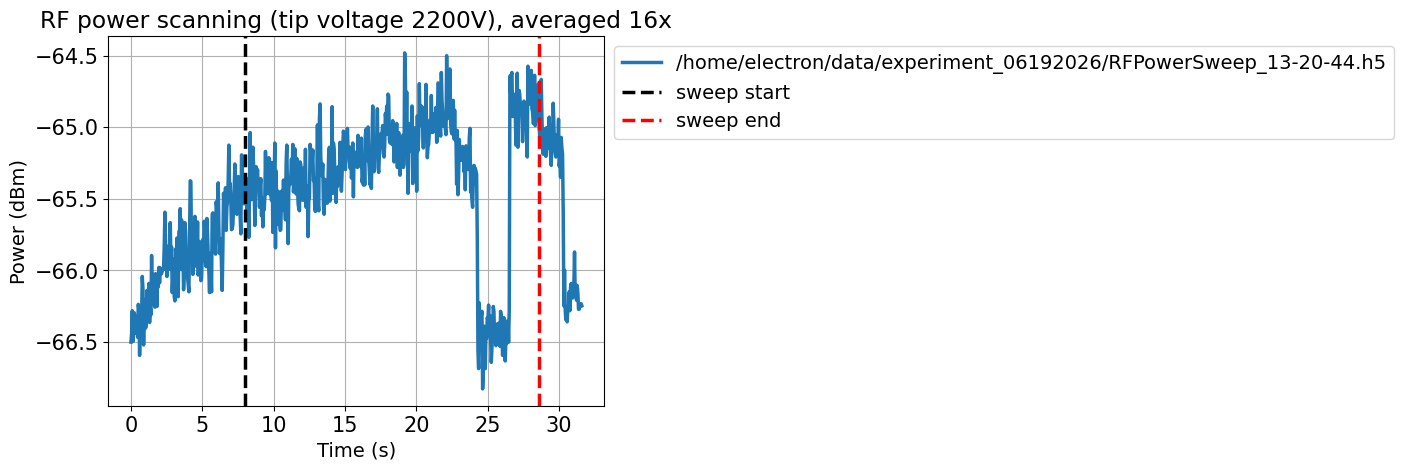

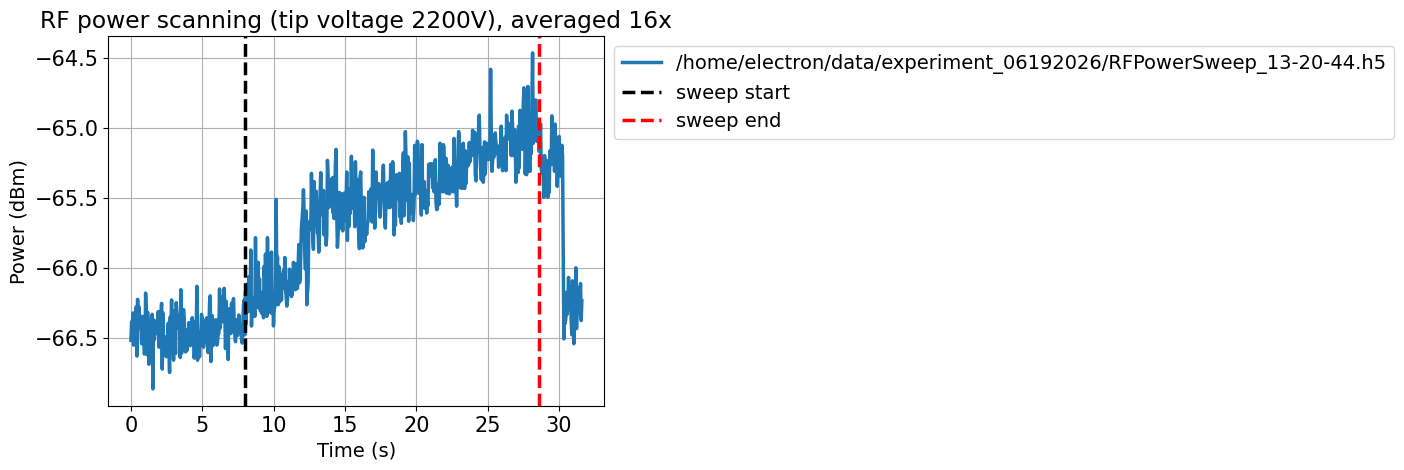

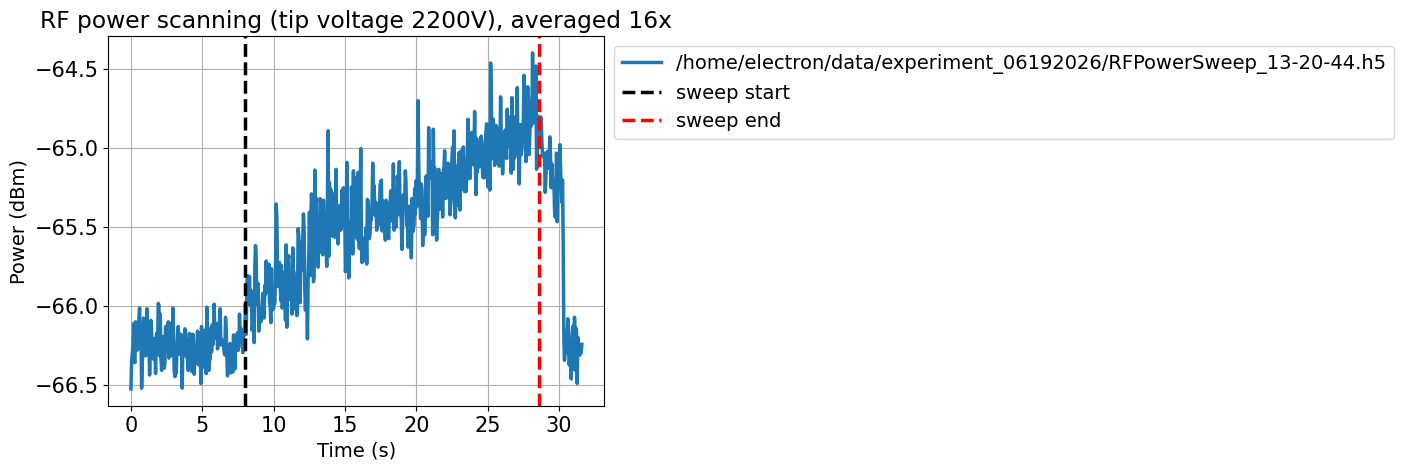

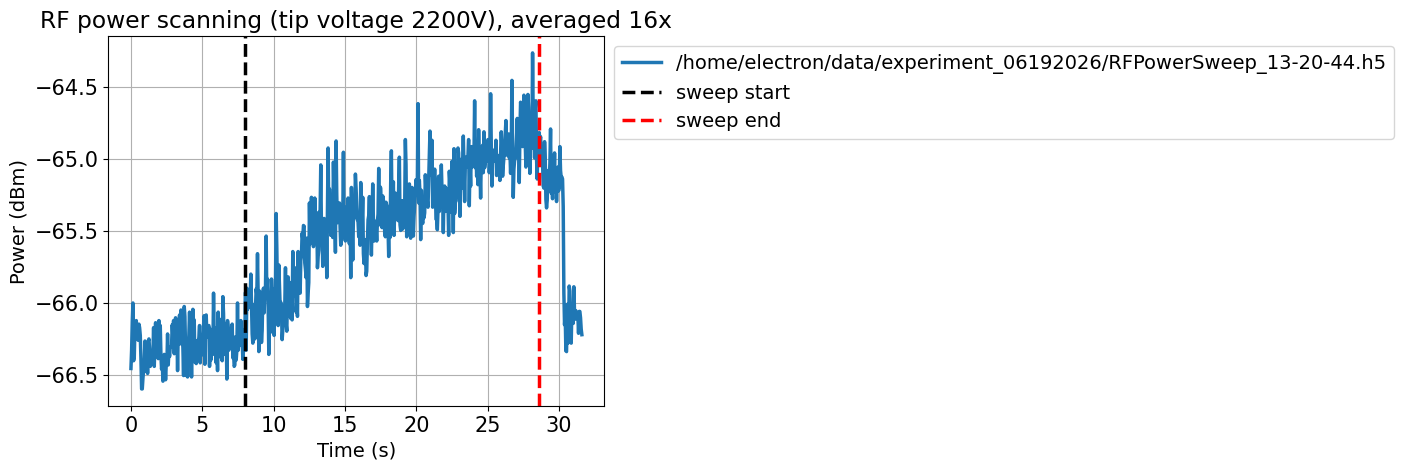

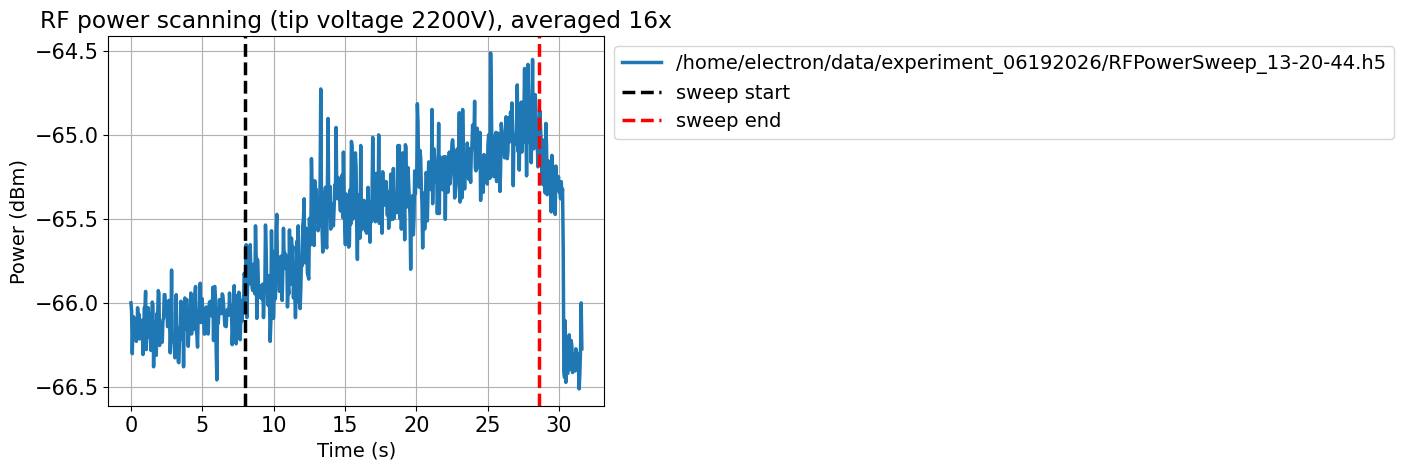

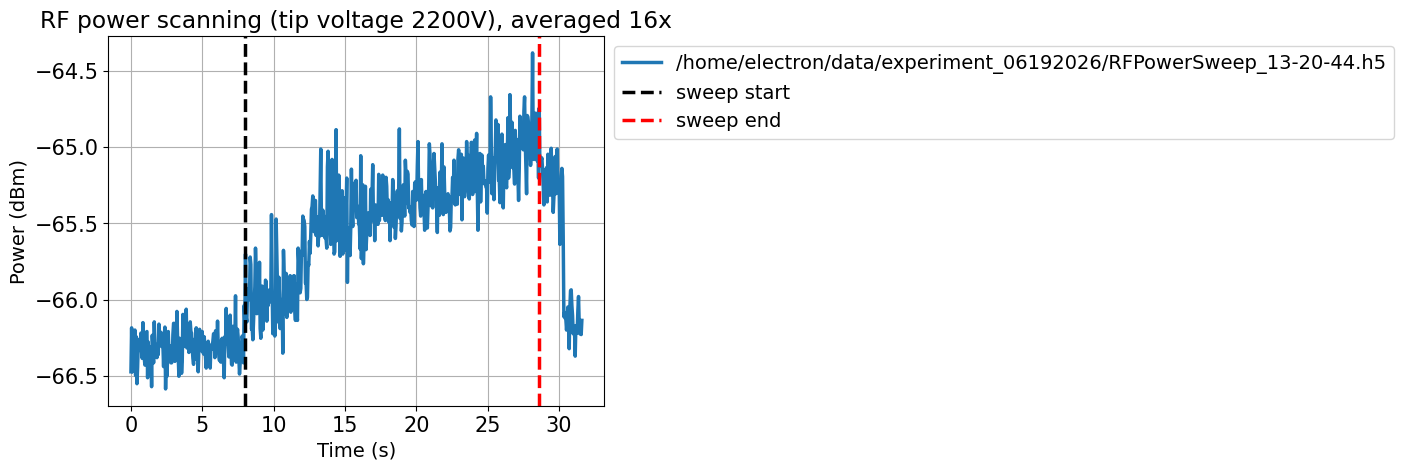

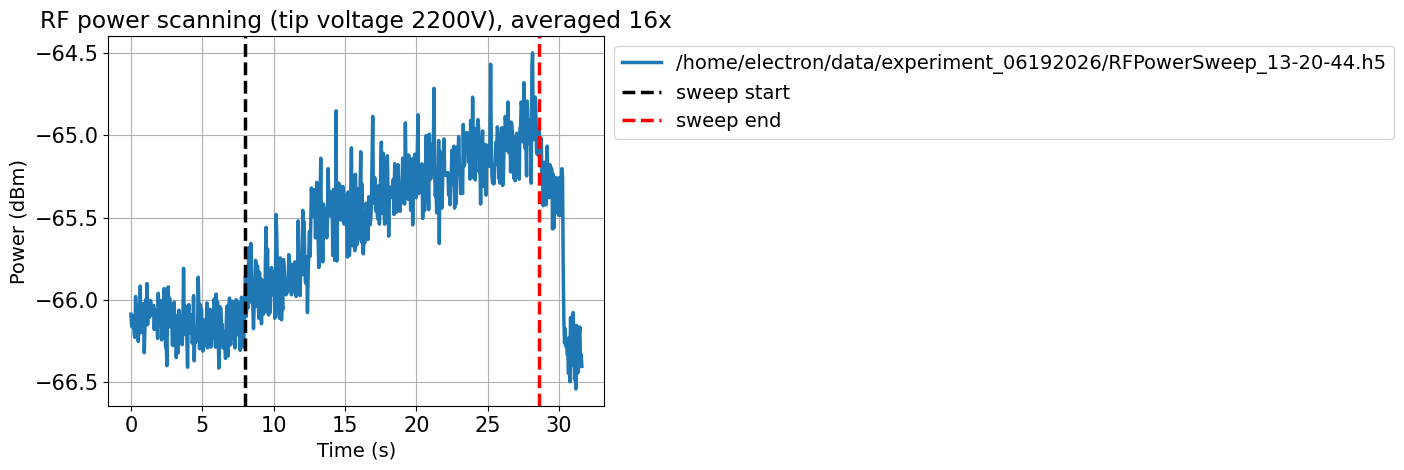

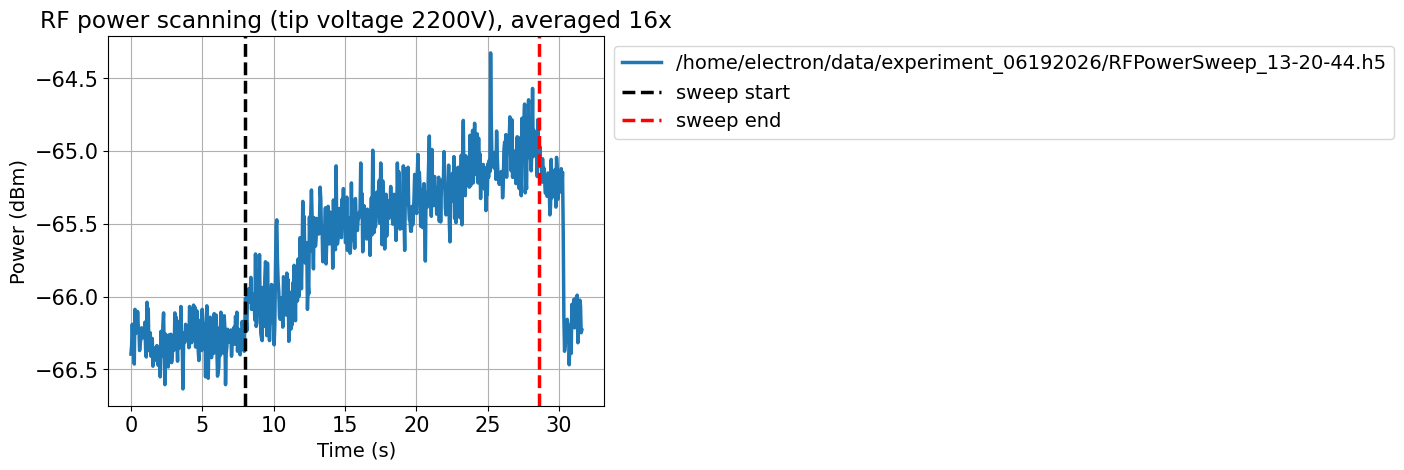

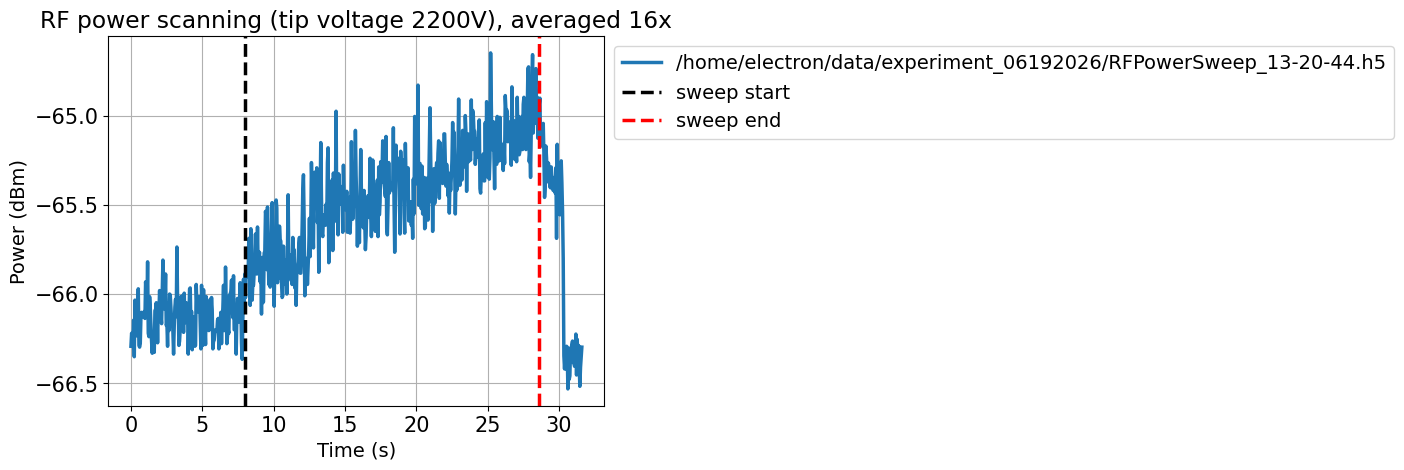

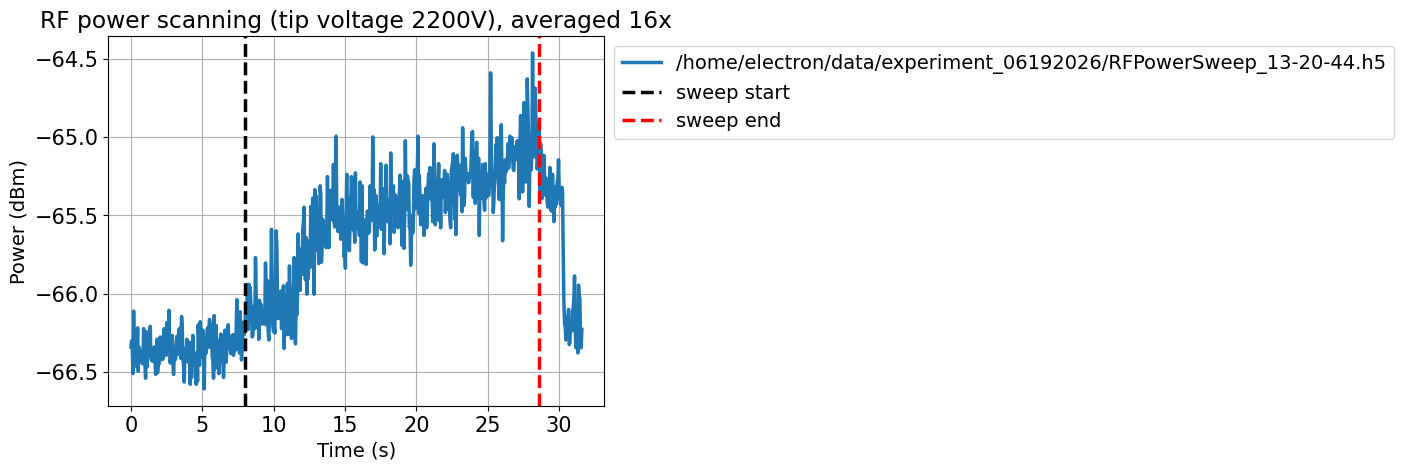

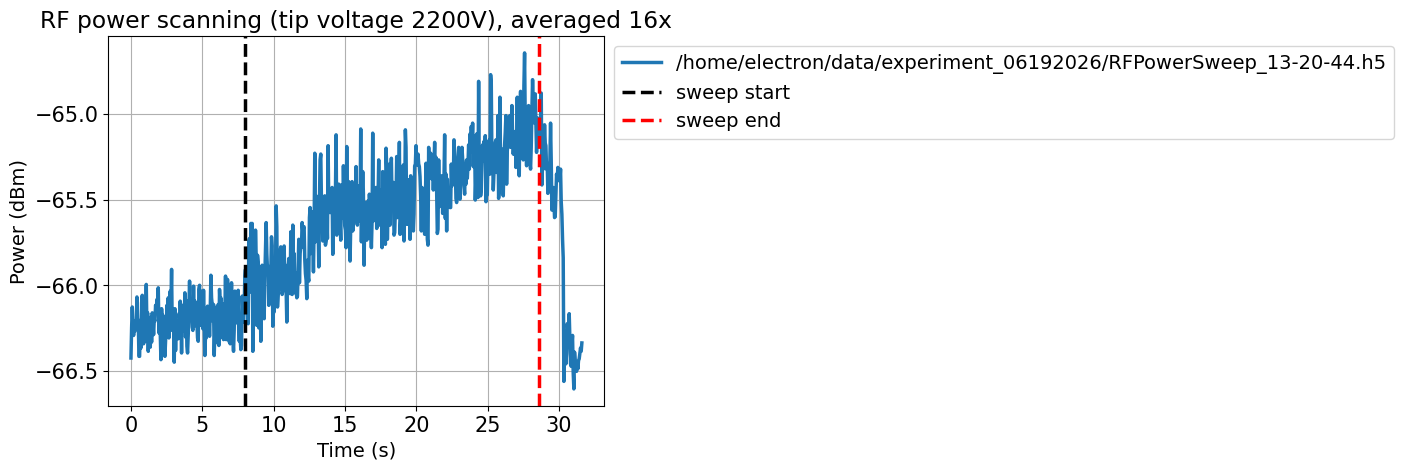

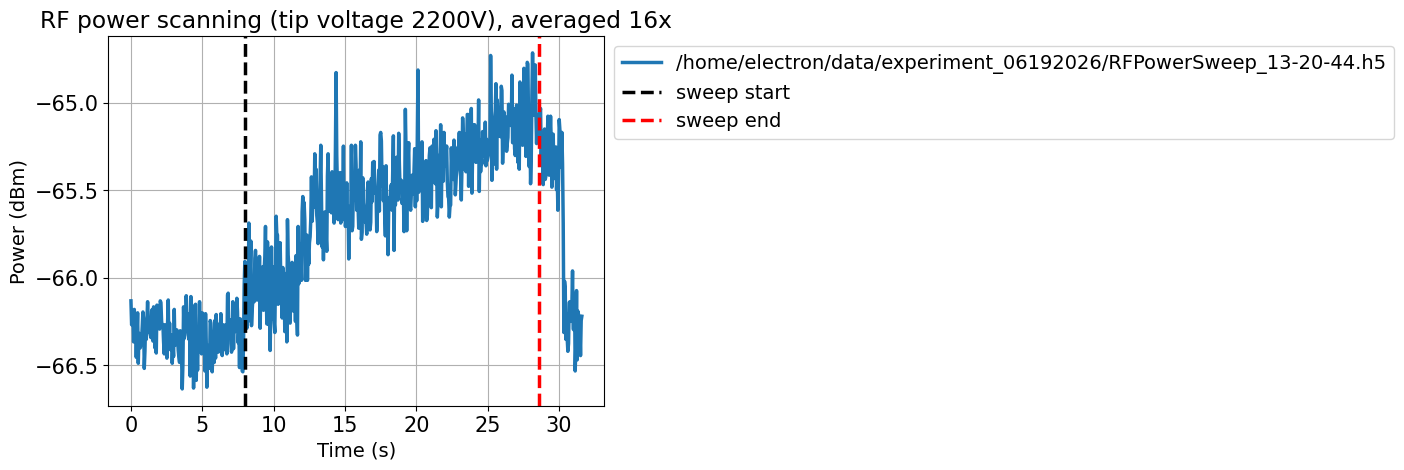

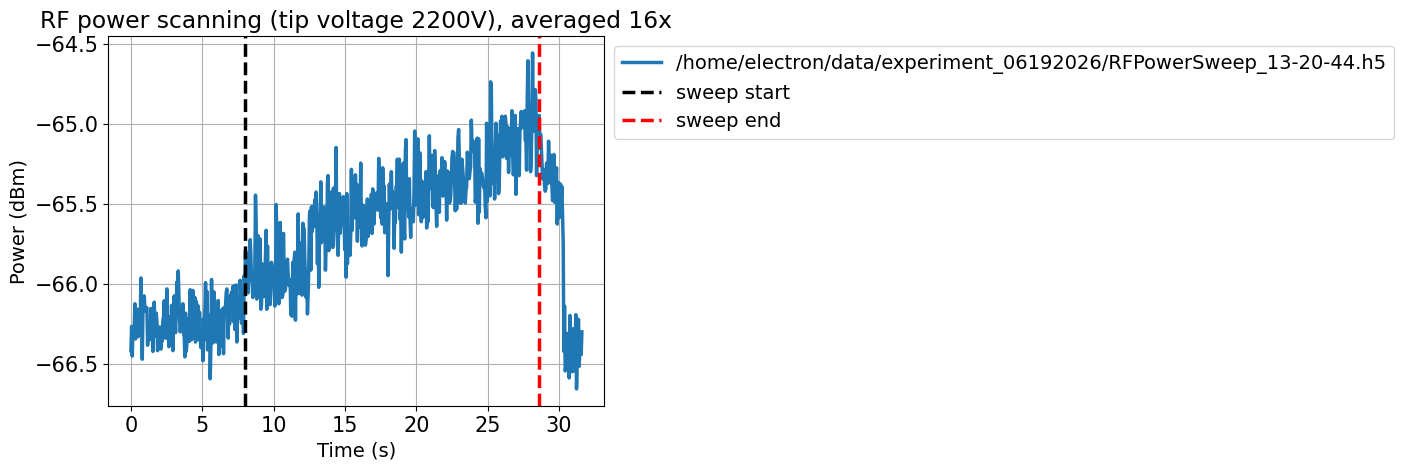

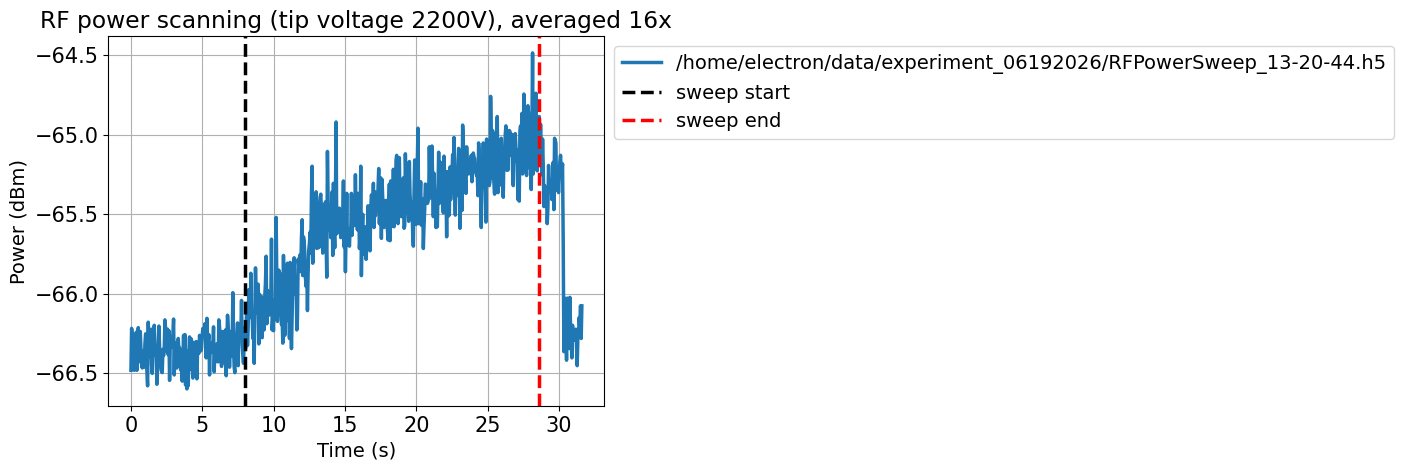

In [25]:
file = load_latest_data()
for i in range(len(file['all_meas'])-1):
    all_data = file['all_meas'][i:i+1]
    num_points = len(all_data[0])
    t_axis = np.linspace(0, file['SSA_SWT'], num_points) 
    idx = np.where(t_axis < file['t_end'][-1]-file['t_start'][-1]+file['t_valon_settle']+file['t_meas_delay']-1)
    plot(t_axis[idx], np.mean(all_data, axis=0)[idx], xlabel='Time (s)', 
         ylabel='Power (dBm)', label=file['filename'], title=f"RF power scanning (tip voltage {file['V_on']}V), averaged {file['N_avg']}x")
    plt.axvline(file['t_valon_settle'], linestyle='--', color='k', label='sweep start')
    plt.axvline(file['t_end'][-1]-file['t_start'][-1]+file['t_valon_settle'], linestyle='--', color='r', label='sweep end') 
    # plt.axvline(t_RF_on, linestyle='--', color='g', label='RF on') 
    # plt.axvline(t_RF_off, linestyle='--', color='purple', label='RF off')
    plt.legend(bbox_to_anchor=(1,1))
    plt.show()


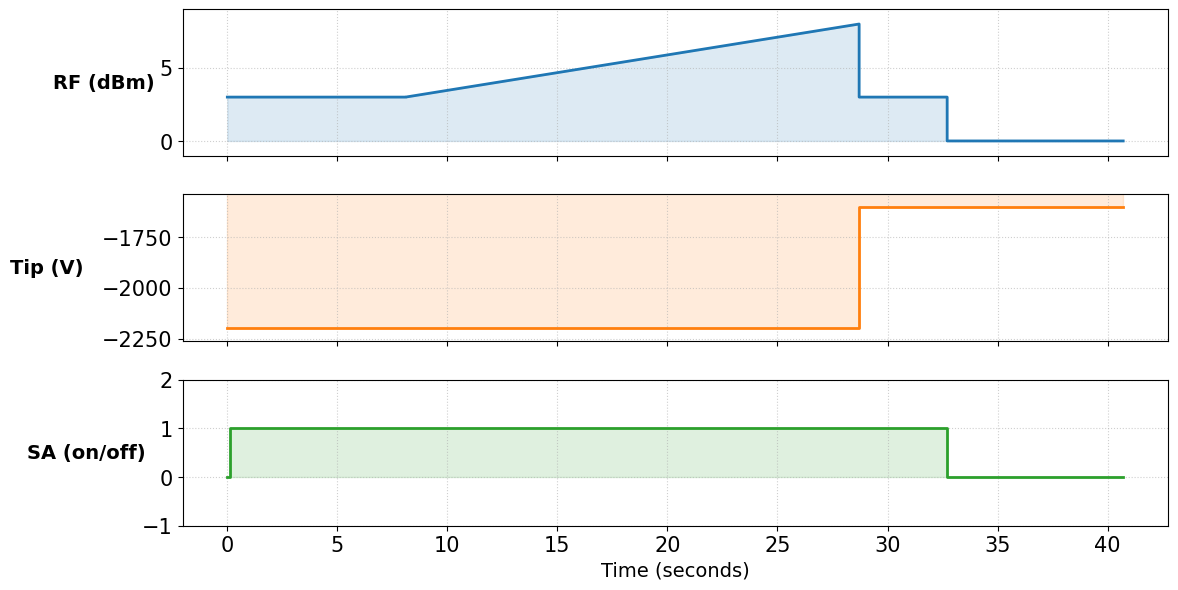

In [18]:
# --- Program Your Sequence Here ---
rf_program = [
    ('flat', 0.1, file['dBm_scan'][0]),                # Value is 3 at time 1s (0s to 1s)
    ('flat', file['t_valon_settle'], file['dBm_scan'][0]),               
    ('linear_sweep', file['t_end'][-1]-file['t_start'][-1], 3.0, 8.0),  # Sweeps from 3 to 8 for 20s
    ('flat', file['t_meas_delay'], file['dBm_scan'][0]),                # Drops back to 3 for 1s
    ('flat', file['t_valon_settle'], 0.0)                 # Goes to 0 for 8s
]
tip = [
    ('flat', 0.1, -file['V_on']),                # Value is 3 at time 1s (0s to 1s)
    ('flat', file['t_valon_settle'], -file['V_on']),               
    ('flat', file['t_end'][-1]-file['t_start'][-1], -file['V_on']),  # Sweeps from 3 to 8 for 20s
    ('flat', file['t_meas_delay'], -file['V_off']),                # Drops back to 3 for 1s
    ('flat', file['t_valon_settle'], -file['V_off'])                 # Goes to 0 for 8s
]
SSA = [
    ('flat', 0.1, 0),                # Value is 3 at time 1s (0s to 1s)
    ('flat', file['t_valon_settle'], 1),               
    ('flat', file['t_end'][-1]-file['t_start'][-1], 1),  # Sweeps from 3 to 8 for 20s
    ('flat', file['t_meas_delay'], 1),                # Drops back to 3 for 1s
    ('flat', file['t_valon_settle'], 0)                 # Goes to 0 for 8s
]

# Compile the program into raw timeline data
compiled_signals = {
    "RF (dBm)": generate_signal_timeline(rf_program),
    "Tip (V)": generate_signal_timeline(tip), 
    "SA (on/off)": generate_signal_timeline(SSA)
}

# Plot the result
plot_generated_timelines(compiled_signals)

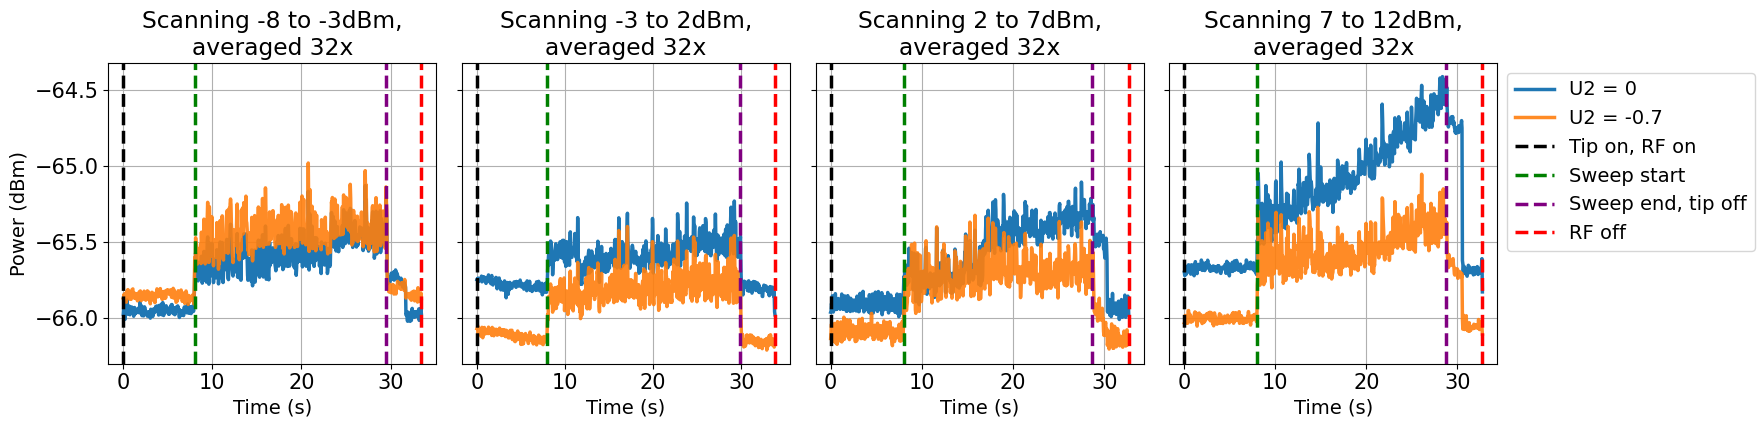

In [8]:
files = ['RFPowerSweep_17-24-48', 'RFPowerSweep_17-49-11', 'RFPowerSweep_18-12-59', 'RFPowerSweep_18-36-50']
files2 = ['RFPowerSweep_15-00-25', 'RFPowerSweep_15-24-49', 'RFPowerSweep_15-48-37', 'RFPowerSweep_16-12-27']
fig, ax = plt.subplots(ncols=4, sharey=True, figsize=(18,4.5))
for i in range(4):
    filename = files2[i]
    file = load_h5_data(filename+'.h5', base=f'{edes.load_saving_dir()}/experiment_06192026')
    all_data = file['all_meas']
    num_points = len(all_data[0])
    t_axis = np.linspace(0, file['SSA_SWT'], num_points) 
    idx = np.where(t_axis < file['t_end'][-1]-file['t_start'][-1]+file['t_valon_settle']+file['t_meas_delay'])
    plot_ax(ax[i], t_axis[idx], np.mean(all_data, axis=0)[idx], xlabel='Time (s)', alpha=1, 
         label=f"U2 = 0" if i == 3 else None, title=f"Scanning {file['dBm_scan'][0]:.0f} to {file['dBm_scan'][-1]:.0f}dBm,\naveraged {file['N_avg']}x")
    filename = files[i]
    file = load_h5_data(filename+'.h5', base=f'{edes.load_saving_dir()}/experiment_06192026')
    all_data = file['all_meas']
    num_points = len(all_data[0])
    t_axis = np.linspace(0, file['SSA_SWT'], num_points) 
    idx = np.where(t_axis < file['t_end'][-1]-file['t_start'][-1]+file['t_valon_settle']+file['t_meas_delay'])
    plot_ax(ax[i], t_axis[idx], np.mean(all_data, axis=0)[idx], xlabel='Time (s)', alpha=0.9,
         label=f"U2 = -0.7" if i == 3 else None, title=f"Scanning {file['dBm_scan'][0]:.0f} to {file['dBm_scan'][-1]:.0f}dBm,\naveraged {file['N_avg']}x")
    ax[i].axvline(0, linestyle='--', color='k', label='Tip on, RF on')
    ax[i].axvline(file['t_valon_settle'], linestyle='--', color='g', label='Sweep start')
    ax[i].axvline(file['t_end'][-1]-file['t_start'][-1]+file['t_valon_settle'], linestyle='--', color='purple', label='Sweep end, tip off') 
    ax[i].axvline(file['t_end'][-1]-file['t_start'][-1]+file['t_valon_settle']+file['t_meas_delay'], linestyle='--', color='r', label='RF off') 
ax[0].set_ylabel('Power (dBm)')
ax[-1].legend(bbox_to_anchor=(1,1))
plt.tight_layout()
plt.show()
